In [1]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Read the pickle file
with open('../tracker_stubs/ball_detections.pkl', 'rb') as f:
    ball_positions = pickle.load(f)

In [3]:
ball_positions = [x.get(1, []) for x in ball_positions]
df_ball_positions = pd.DataFrame(ball_positions, columns = ['x1', 'y1', 'x2', 'y2'])

# Interpolate the missing values
df_ball_positions = df_ball_positions.interpolate()
df_ball_positions = df_ball_positions.bfill()

In [4]:
df_ball_positions.head(10)

,x1,y1,x2,y2
0,895.415771,618.071777,912.313477,635.559631
1,895.415771,618.071777,912.313477,635.559631
2,873.901245,638.229492,895.586975,658.988586
3,859.940918,645.812683,881.553406,670.207275
4,847.489807,659.532389,867.009216,681.258647
5,835.038696,673.252096,852.465027,692.310018
6,822.587585,686.971802,837.920837,703.361389
7,812.611816,693.643433,832.407898,716.451965
8,797.326233,717.677307,814.770874,738.818909
9,783.110748,738.475525,801.490417,759.473633


In [11]:
df_ball_positions['mid_y'] = (df_ball_positions['y1'] + df_ball_positions['y2']) / 2
df_ball_positions['mid_y_rolling_mean_5'] = df_ball_positions['mid_y'].rolling(window = 5, min_periods = 1, center = False).mean()
df_ball_positions['mid_y_rolling_mean_10'] = df_ball_positions['mid_y'].rolling(window = 10, min_periods = 1, center = False).mean()

In [8]:
df_ball_positions.head(5)

,x1,y1,x2,y2,mid_y,mid_y_rolling_mean
0,895.415771,618.071777,912.313477,635.559631,626.815704,626.815704
1,895.415771,618.071777,912.313477,635.559631,626.815704,626.815704
2,873.901245,638.229492,895.586975,658.988586,648.609039,634.080149
3,859.940918,645.812683,881.553406,670.207275,658.009979,640.062607
4,847.489807,659.532389,867.009216,681.258647,670.395518,646.129189


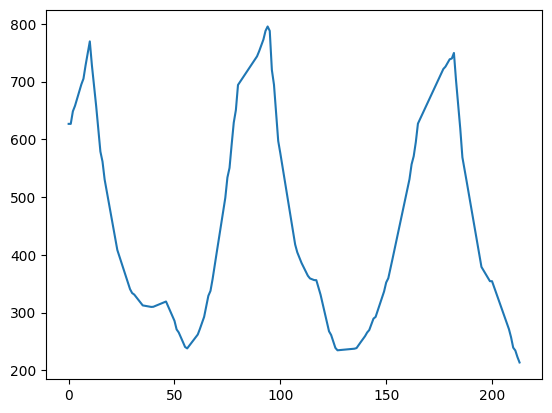

In [9]:
plt.plot(df_ball_positions['mid_y'])

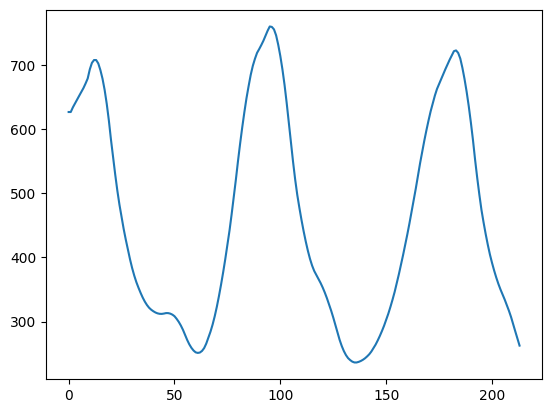

In [13]:
plt.plot(df_ball_positions['mid_y_rolling_mean_10'])